In [ ]:
pip install yfinance pandas numpy torch scikit-learn ta matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=fe506b7c74be66c5e989da33d25525e1b1068db129c68331a78edde5671a6b19
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]

for t in tickers:
    print(f"\nProcessing {t}...")
    df = yf.download(t, start="2015-01-01", auto_adjust=True)
    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
    df["volatility_5d"] = df["log_return"].rolling(5).std().shift(-5)
    df["ma_10"] = df["Close"].rolling(10).mean()
    df["ma_50"] = df["Close"].rolling(50).mean()
    df["volume_change"] = df["Volume"].pct_change()
    df["volume_ma_10"] = df["Volume"].rolling(10).mean()
    df = df.dropna()
    df_final = df[[
        "log_return",
        "ma_10",
        "ma_50",
        "volume_change",
        "volume_ma_10",
        "volatility_5d"
    ]]
    df_final.to_csv(f"{t}_volatility_dataset.csv")
    print("Saved:", f"{t}_volatility_dataset.csv")
    print(df_final.tail())



Processing RELIANCE.NS...


[*********************100%***********************]  1 of 1 completed


Saved: RELIANCE.NS_volatility_dataset.csv
Price      log_return        ma_10        ma_50 volume_change volume_ma_10  \
Ticker                                                                       
Date                                                                         
2026-03-20   0.021150  1399.589990  1418.740005      0.393769   19389338.1   
2026-03-23  -0.004677  1397.969995  1417.484006     -0.174620   18800211.3   
2026-03-24   0.002837  1398.269995  1416.214006     -0.018897   18855174.7   
2026-03-25   0.000920  1400.559998  1414.812007      0.022579   18574499.1   
2026-03-27  -0.047090  1396.150000  1412.718005      0.221896   18807154.9   

Price      volatility_5d  
Ticker                    
Date                      
2026-03-20      0.020827  
2026-03-23      0.024644  
2026-03-24      0.024346  
2026-03-25      0.025887  
2026-03-27      0.019166  

Processing TCS.NS...


[*********************100%***********************]  1 of 1 completed


Saved: TCS.NS_volatility_dataset.csv
Price      log_return        ma_10        ma_50 volume_change volume_ma_10  \
Ticker                                                                       
Date                                                                         
2026-03-20   0.014579  2434.659985  2828.756694      0.525654    3276340.7   
2026-03-23  -0.002849  2420.300000  2813.498770     -0.082211    3297049.4   
2026-03-24   0.006273  2408.869995  2798.464233     -0.114061    3206696.6   
2026-03-25  -0.008961  2400.119995  2782.377046      0.708616    3519008.0   
2026-03-27   0.005202  2394.860010  2765.980005     -0.147912    3741741.6   

Price      volatility_5d  
Ticker                    
Date                      
2026-03-20      0.008494  
2026-03-23      0.013446  
2026-03-24      0.015157  
2026-03-25      0.013252  
2026-03-27      0.014214  

Processing INFY.NS...


[*********************100%***********************]  1 of 1 completed

Saved: INFY.NS_volatility_dataset.csv
Price      log_return        ma_10        ma_50 volume_change volume_ma_10  \
Ticker                                                                       
Date                                                                         
2026-03-20   0.028346  1262.750024  1450.704006      1.981499   11486315.7   
2026-03-23   0.000716  1256.930029  1443.574006     -0.545044   11721493.6   
2026-03-24   0.016962  1255.200037  1436.858008      0.096069   12122826.0   
2026-03-25   0.000626  1255.480029  1430.522007     -0.204904   12418339.9   
2026-03-27  -0.007376  1255.870020  1423.936006      0.209581   12967600.0   

Price      volatility_5d  
Ticker                    
Date                      
2026-03-20      0.011929  
2026-03-23      0.015187  
2026-03-24      0.015797  
2026-03-25      0.015716  
2026-03-27      0.014659  


In [ ]:
#download all the data
import yfinance as yf
import pandas as pd
import numpy as np
import os

os.makedirs("data/raw",exist_ok=True)
os.makedirs("data/processed",exist_ok=True)
os.makedirs("data/plots",exist_ok=True)

TICKERS={
    "IT":["TCS.NS","INFY.NS","WIPRO.NS","HCLTECH.NS","TECHM.NS"],
    "Banking":["HDFCBANK.NS","ICICIBANK.NS","SBIN.NS","KOTAKBANK.NS","AXISBANK.NS"],
    "Energy":["RELIANCE.NS","ONGC.NS","NTPC.NS","POWERGRID.NS","BPCL.NS"],
    "Pharma":["SUNPHARMA.NS","DRREDDY.NS","CIPLA.NS","DIVISLAB.NS","APOLLOHOSP.NS"],
    "FMCG":["HINDUNILVR.NS","ITC.NS","NESTLEIND.NS","BRITANNIA.NS","MARICO.NS"],
}

ALL_TICKERS=[t for sector in TICKERS.values() for t in sector]
SECTOR_MAP={t:s for s,tickers in TICKERS.items() for t in tickers}
SECTOR_ID={s:i for i,s in enumerate(TICKERS.keys())}
TICKER_ID={t:i for i,t in enumerate(ALL_TICKERS)}

START="2015-01-01"
END="2024-12-31"

def flatten_cols(df):
    #remove multi index columns
    if isinstance(df.columns,pd.MultiIndex):
        df.columns=df.columns.get_level_values(0)
    return df

print("Downloading India VIX...")
india_vix=yf.download("^INDIAVIX",start=START,end=END,auto_adjust=True)
india_vix=flatten_cols(india_vix)[["Close"]].copy()
india_vix.columns=["INDIAVIX"]
india_vix.index=pd.to_datetime(india_vix.index).tz_localize(None)
india_vix.to_csv("data/raw/INDIAVIX.csv")
print(f"India VIX rows:{len(india_vix)}")

print("Downloading Nifty 50...")
nifty=yf.download("^NSEI",start=START,end=END,auto_adjust=True)
nifty=flatten_cols(nifty)[["Close"]].copy()
nifty.columns=["NIFTY_Close"]
nifty.index=pd.to_datetime(nifty.index).tz_localize(None)
nifty["NIFTY_return"]=np.log(nifty["NIFTY_Close"]/nifty["NIFTY_Close"].shift(1))
nifty.to_csv("data/raw/NIFTY50.csv")
print(f"Nifty 50 rows:{len(nifty)}")

all_dfs=[]
errors=[]

#calculate the different features
for ticker in ALL_TICKERS:
    print(f"\nProcessing {ticker}...")
    try:
        raw=yf.download(ticker,start=START,end=END,
                        auto_adjust=True,progress=False)

        raw=flatten_cols(raw)
        raw.index=pd.to_datetime(raw.index).tz_localize(None)

        if len(raw)<200:
            print(f"  Skipping — only {len(raw)} rows")
            continue

        df=pd.DataFrame(index=raw.index)
        df["Open"]=raw["Open"].squeeze()
        df["High"]=raw["High"].squeeze()
        df["Low"]=raw["Low"].squeeze()
        df["Close"]=raw["Close"].squeeze()
        df["Volume"]=raw["Volume"].squeeze()

        df["log_return"]=np.log(df["Close"]/df["Close"].shift(1))
        df["volatility_5d_future"]=df["log_return"].rolling(5).std().shift(-5)
        df["volatility_5d_hist"]=df["log_return"].rolling(5).std()

        df["ma_10"]=df["Close"].rolling(10).mean()
        df["ma_20"]=df["Close"].rolling(20).mean()
        df["ma_50"]=df["Close"].rolling(50).mean()

        df["volume_change"]=df["Volume"].pct_change()
        df["volume_ma_10"]=df["Volume"].rolling(10).mean()
        df["volume_ratio"]=df["Volume"]/df["volume_ma_10"].replace(0,np.nan)

        df=df.join(india_vix,how="left")
        df=df.join(nifty[["NIFTY_return"]],how="left")
        df["INDIAVIX"]=df["INDIAVIX"].ffill()
        df["NIFTY_return"]=df["NIFTY_return"].ffill()

        df["ticker"]=ticker
        df["sector"]=SECTOR_MAP[ticker]
        df["ticker_id"]=TICKER_ID[ticker]
        df["sector_id"]=SECTOR_ID[SECTOR_MAP[ticker]]

        df.to_csv(f"data/raw/{ticker.replace('.NS','')}.csv")

        keep=[
            "ticker","sector","ticker_id","sector_id",
            "Open","High","Low","Close","Volume",
            "log_return","volatility_5d_hist",
            "ma_10","ma_20","ma_50",
            "volume_change","volume_ma_10","volume_ratio",
            "INDIAVIX","NIFTY_return",
            "volatility_5d_future",
        ]
        df_clean=df[keep].dropna()
        all_dfs.append(df_clean)
        print(f"  OK — {len(df_clean)} rows | sector:{SECTOR_MAP[ticker]}")

    except Exception as e:
        print(f"  ERROR:{e}")
        errors.append((ticker,str(e)))

if errors:
    print("\nFailed tickers:")
    for t,e in errors:
        print(f"  {t}:{e}")

if not all_dfs:
    raise RuntimeError("No stock data collected — check errors above.")

combined=pd.concat(all_dfs)
combined.index.name="Date"
combined.to_csv("data/processed/all_stocks_india.csv")

print(f"\nDone. Combined shape:{combined.shape}")
print(combined["ticker"].value_counts().to_string())


[*********************100%***********************]  1 of 1 completed


India VIX rows:2450


[*********************100%***********************]  1 of 1 completed


Nifty 50 rows:2458

Processing TCS.NS...
  OK — 2412 rows | sector:IT

Processing INFY.NS...
  OK — 2412 rows | sector:IT

Processing WIPRO.NS...
  OK — 2412 rows | sector:IT

Processing HCLTECH.NS...
  OK — 2412 rows | sector:IT

Processing TECHM.NS...
  OK — 2412 rows | sector:IT

Processing HDFCBANK.NS...
  OK — 2412 rows | sector:Banking

Processing ICICIBANK.NS...
  OK — 2412 rows | sector:Banking

Processing SBIN.NS...
  OK — 2412 rows | sector:Banking

Processing KOTAKBANK.NS...
  OK — 2412 rows | sector:Banking

Processing AXISBANK.NS...
  OK — 2412 rows | sector:Banking

Processing RELIANCE.NS...
  OK — 2412 rows | sector:Energy

Processing ONGC.NS...
  OK — 2412 rows | sector:Energy

Processing NTPC.NS...
  OK — 2412 rows | sector:Energy

Processing POWERGRID.NS...
  OK — 2412 rows | sector:Energy

Processing BPCL.NS...
  OK — 2412 rows | sector:Energy

Processing SUNPHARMA.NS...
  OK — 2412 rows | sector:Pharma

Processing DRREDDY.NS...
  OK — 2412 rows | sector:Pharma

Proc

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

df = pd.read_csv("data/processed/all_stocks_india.csv",
                 index_col="Date", parse_dates=True)

vix = pd.read_csv("data/raw/INDIAVIX.csv",
                  index_col=0, parse_dates=True)

print(f"Dataset: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Tickers: {df['ticker'].nunique()}")
df.head()

Dataset: (60300, 20)
Date range: 2015-03-16 → 2024-12-20
Tickers: 25


,ticker,sector,ticker_id,sector_id,Open,High,Low,Close,Volume,log_return,volatility_5d_hist,ma_10,ma_20,ma_50,volume_change,volume_ma_10,volume_ratio,INDIAVIX,NIFTY_return,volatility_5d_future
Date,,,,,,,,,,,,,,,,,,,,
2015-03-16,TCS.NS,IT,0,0,1006.292171,1015.945620,993.369051,997.378357,1556296,-0.007795,0.008130,1033.368616,1032.601828,998.498524,-0.019247,2476805.0,0.628348,15.18,-0.001690,0.008825
2015-03-17,TCS.NS,IT,0,0,1005.241536,1014.661399,995.607565,1005.708618,1267318,0.008317,0.010485,1030.032776,1033.476669,998.835101,-0.185683,2385933.0,0.531162,15.13,0.010388,0.010355
2015-03-18,TCS.NS,IT,0,0,1008.530631,1011.839267,993.252517,996.230347,1255170,-0.009469,0.009681,1021.599658,1032.981348,998.718733,-0.009586,2169019.2,0.578681,15.51,-0.004297,0.009757
2015-03-19,TCS.NS,IT,0,0,1002.710987,1014.330172,999.635941,1010.593323,2448964,0.014314,0.012332,1015.770624,1032.214511,999.194181,0.951101,2027616.2,1.207805,15.20,-0.005918,0.011608
2015-03-20,TCS.NS,IT,0,0,1010.496264,1019.059792,1003.820643,1016.315552,1963908,0.005646,0.010394,1012.442511,1030.850180,1000.511689,-0.198066,2006655.6,0.978697,14.26,-0.007410,0.010463


Pearson correlation (avg stock vol vs India VIX): 0.7097


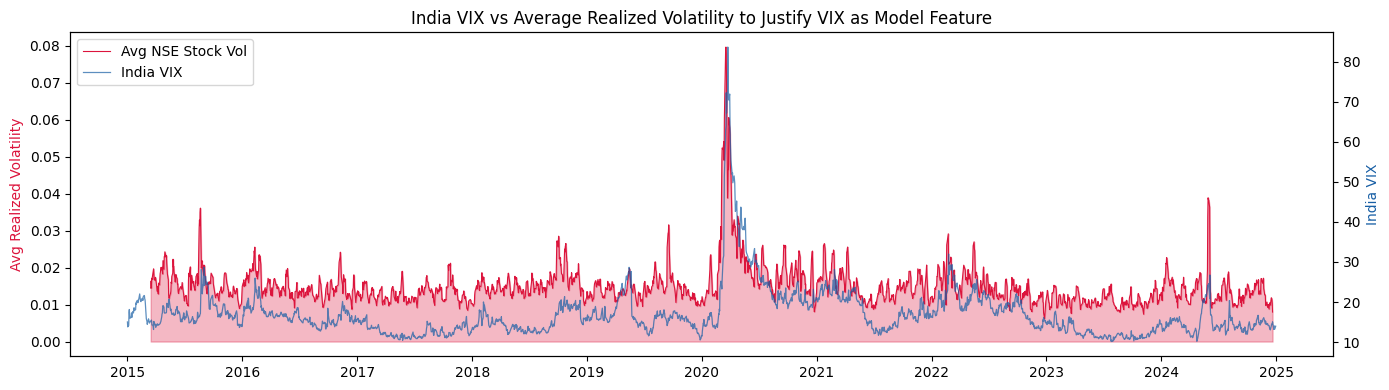

In [ ]:
#we need to justify vix since it doesn't directly come from the stock data
daily_vol = df.groupby(df.index)["volatility_5d_future"].mean()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.fill_between(daily_vol.index, daily_vol.values,
                 alpha=0.3, color="crimson")
ax1.plot(daily_vol.index, daily_vol.values,
         color="crimson", linewidth=0.8, label="Avg NSE Stock Vol")

ax2.plot(vix.index, vix["INDIAVIX"].values,
         color="#185FA5", linewidth=0.9, alpha=0.7, label="India VIX")

ax1.set_ylabel("Avg Realized Volatility", color="crimson")
ax2.set_ylabel("India VIX", color="#185FA5")
ax1.set_title("India VIX vs Average Realized Volatility to Justify VIX as Model Feature")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

aligned = pd.concat([
    daily_vol.rename("avg_vol"),
    vix["INDIAVIX"].reindex(daily_vol.index).ffill()
], axis=1).dropna()
print(f"Pearson correlation (avg stock vol vs India VIX): "
      f"{aligned.corr().iloc[0,1]:.4f}")

plt.tight_layout()
plt.savefig("data/plots/04_vix_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

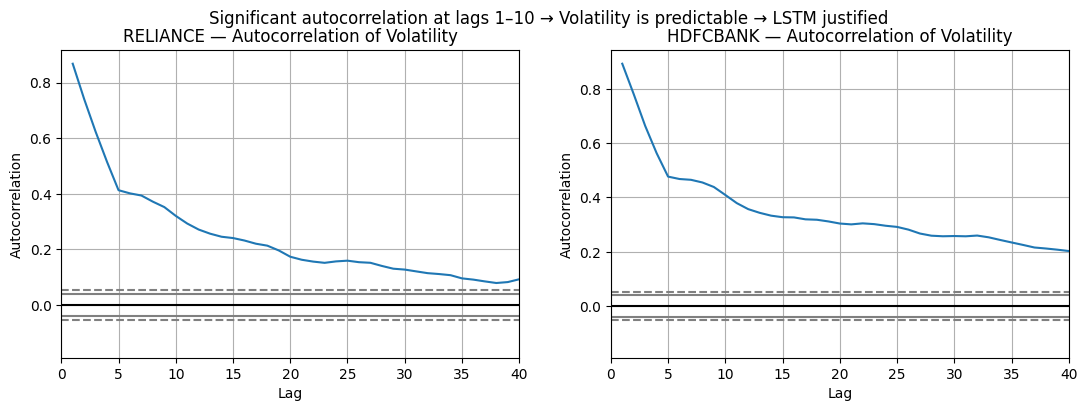

In [ ]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rel_vol = df[df["ticker"] == "RELIANCE.NS"]["volatility_5d_future"].dropna()
autocorrelation_plot(rel_vol, ax=axes[0])
axes[0].set_xlim(0, 40)
axes[0].set_title("RELIANCE — Autocorrelation of Volatility")
axes[0].axhline(0, color="black", linewidth=0.5)

hdf_vol = df[df["ticker"] == "HDFCBANK.NS"]["volatility_5d_future"].dropna()
autocorrelation_plot(hdf_vol, ax=axes[1])
axes[1].set_xlim(0, 40)
axes[1].set_title("HDFCBANK — Autocorrelation of Volatility")
axes[1].axhline(0, color="black", linewidth=0.5)

plt.suptitle("Significant autocorrelation at lags 1–10 → Volatility is predictable → LSTM justified")

plt.show()

In [ ]:
import pandas as  pd
from transformers import pipeline
import time

finbert=pipeline("text-classification", model="ProsusAI/finbert", top_k=None)
def headline_score(result):
  scores={}
  for r in result:
    scores[r["label"]]=r["score"]
  return scores["positive"] - scores["negative"]


news_df=pd.read_csv("IndianFinancialNews.csv")
news_df=news_df.drop(columns=["Unnamed: 0"])
news_df["Date"]=pd.to_datetime(news_df["Date"], format="%B %d, %Y, %A")
print(news_df.shape)
print(news_df.head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(50000, 3)
        Date                                              Title  \
0 2020-05-26  ATMs to become virtual bank branches, accept d...   
1 2020-05-26  IDFC First Bank seniors to forgo 65% of bonus ...   
2 2020-05-25  Huge scam in YES Bank for many years, says Enf...   
3 2020-05-24  Bank of Maharashtra sanctioned Rs 2,789 cr in ...   
4 2020-05-23  DCB Bank's profit before tax declines 37.6% to...   

                                         Description  
0  Close to 14.6 per cent (or 35,000) of the 240,...  
1  V Vaidyanathan, managing director and chief ex...  
2  Rana Kapoor's wife also charged with abetting ...  
3  The bank said it was now gearing up to extend ...  
4  Net profit for the financial year ended March ...  


In [ ]:
news_df["text"]=news_df["Title"]+". "+news_df["Description"].fillna("")
news_df=news_df[news_df["Date"].dt.year >= 2015]
news_df = news_df.groupby("Date").head(5)


daily_sentiment=[]
all_dates=news_df["Date"].unique()

for date in all_dates:
  day_headlines=news_df[news_df["Date"]==date]["text"].tolist()
  day_scores=[]
  for headline in day_headlines:
    result=finbert(headline, truncation=True, max_length=512)
    score=headline_score(result[0])
    day_scores.append(score)
  avg_score=sum(day_scores)/len(day_scores)
  daily_sentiment.append({
      "Date":date,
      "sentiment":avg_score
  })
  print(f"{date.date()} | Headlines: {len(day_headlines)} | Sentiment: {avg_score:.3f}")


2020-05-26 | Headlines: 2 | Sentiment: -0.334
2020-05-25 | Headlines: 1 | Sentiment: -0.547
2020-05-24 | Headlines: 1 | Sentiment: 0.863
2020-05-23 | Headlines: 2 | Sentiment: 0.513
2020-05-22 | Headlines: 5 | Sentiment: -0.087
2020-05-21 | Headlines: 5 | Sentiment: -0.289
2020-05-20 | Headlines: 3 | Sentiment: -0.630
2020-05-19 | Headlines: 3 | Sentiment: -0.594
2020-05-18 | Headlines: 1 | Sentiment: 0.147
2020-05-17 | Headlines: 1 | Sentiment: -0.549
2020-05-15 | Headlines: 1 | Sentiment: 0.119
2020-05-14 | Headlines: 3 | Sentiment: -0.103
2020-05-13 | Headlines: 2 | Sentiment: -0.073
2020-05-12 | Headlines: 2 | Sentiment: 0.025
2020-05-11 | Headlines: 2 | Sentiment: 0.017
2020-05-10 | Headlines: 2 | Sentiment: 0.800
2020-05-09 | Headlines: 3 | Sentiment: 0.209
2020-05-08 | Headlines: 5 | Sentiment: -0.181
2020-05-07 | Headlines: 5 | Sentiment: -0.135
2020-05-06 | Headlines: 5 | Sentiment: -0.148
2020-05-05 | Headlines: 2 | Sentiment: -0.038
2020-05-04 | Headlines: 5 | Sentiment: -0.

In [ ]:
sentiment_df=pd.DataFrame(daily_sentiment)
sentiment_df=sentiment_df.sort_values("Date")
sentiment_df=sentiment_df.set_index("Date")
sentiment_df.to_csv("data/raw/sentiment_scores.csv")
print(f"Saved {len(sentiment_df)} days of sentiment scores")
print(sentiment_df.head())

Saved 1924 days of sentiment scores
            sentiment
Date                 
2015-01-01  -0.155136
2015-01-02   0.418057
2015-01-03  -0.149721
2015-01-04   0.017638
2015-01-05   0.816162


In [ ]:
import pandas as pd
df=pd.read_csv("data/processed/all_stocks_india.csv", index_col="Date", parse_dates=True)
sentiment_df=pd.read_csv("data/raw/sentiment_scores.csv",index_col="Date", parse_dates=True)
print("Main dataset shape: ", df.shape)
print("Sentiment dataset shape:", sentiment_df.shape)
df=df.join(sentiment_df, how="left")
df["sentiment"]=df["sentiment"].ffill()
df["sentiment"]=df["sentiment"].fillna(0)
df.to_csv("data/processed/all_stocks_india_sentiment.csv")
print(f"Saved merged dataset: data/processed/all_stocks_india_sentiment.csv")
print("Shape:", df.shape)
print(df[["ticker", "sentiment"]].head(10))

Main dataset shape:  (60300, 20)
Sentiment dataset shape: (1924, 1)
Saved merged dataset: data/processed/all_stocks_india_sentiment.csv
Shape: (60300, 21)
            ticker  sentiment
Date                         
2015-03-16  TCS.NS  -0.017224
2015-03-17  TCS.NS  -0.109196
2015-03-18  TCS.NS  -0.041896
2015-03-19  TCS.NS   0.279621
2015-03-20  TCS.NS   0.339143
2015-03-23  TCS.NS   0.409744
2015-03-24  TCS.NS   0.131118
2015-03-25  TCS.NS   0.744267
2015-03-26  TCS.NS  -0.183130
2015-03-27  TCS.NS  -0.157330


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
SEQUENCE_LEN=20
BATCH_SIZE=64
EPOCHS=25
LEARNING_RATE=0.001
HIDDEN_SIZE=64
NUM_LAYERS=1
DROPOUT=0.4

features=[
    "log_return",
    "volatility_5d_hist",
    "ma_10",
    "ma_20",
    "ma_50",
    "volume_change",
    "volume_ma_10",
    "volume_ratio",
    "INDIAVIX",
    "NIFTY_return",
    "sentiment",
    "ticker_id",
    "sector_id",
]

TARGET_REG="volatility_5d_future"
TARGET_CLS="direction"


In [ ]:
df = pd.read_csv("data/processed/all_stocks_india_sentiment.csv", index_col="Date", parse_dates=True)
df = df[df.index.year <= 2020]
df["log_vol_target"] = np.log(df["volatility_5d_future"].clip(1e-5))
TARGET_REG = "log_vol_target"


In [ ]:
df["direction"] = (df["volatility_5d_future"] > df["volatility_5d_hist"]).astype(int)

print("Dataset shape:", df.shape)
print("Direction value counts:\n", df["direction"].value_counts())

Dataset shape: (35775, 23)
Direction value counts:
 direction
0    17976
1    17799
Name: count, dtype: int64


In [ ]:
def build_sequences(ticker_df, features, seq_len):
    X_list      = []
    y_reg_list  = []
    y_cls_list  = []

    values = ticker_df[features].values
    y_reg  = ticker_df[TARGET_REG].values
    y_cls  = ticker_df[TARGET_CLS].values

    for i in range(seq_len, len(values)):
        X_list.append(values[i - seq_len:i])
        y_reg_list.append(y_reg[i])
        y_cls_list.append(y_cls[i])

    return np.array(X_list), np.array(y_reg_list), np.array(y_cls_list)

all_X      = []
all_y_reg  = []
all_y_cls  = []

for ticker in df["ticker"].unique():
    ticker_df = df[df["ticker"] == ticker].sort_index()
    ticker_df = ticker_df.dropna(subset=features + [TARGET_REG, TARGET_CLS])
    ticker_df = ticker_df.replace([np.inf, -np.inf], np.nan)
    ticker_df = ticker_df.dropna(subset=features + [TARGET_REG, TARGET_CLS])

    if len(ticker_df) < SEQUENCE_LEN + 10:
        print(f"Skipping {ticker} — not enough rows")
        continue

    X, y_reg, y_cls = build_sequences(ticker_df, features, SEQUENCE_LEN)
    all_X.append(X)
    all_y_reg.append(y_reg)
    all_y_cls.append(y_cls)

X      = np.concatenate(all_X,     axis=0)
y_reg  = np.concatenate(all_y_reg, axis=0)
y_cls  = np.concatenate(all_y_cls, axis=0)

print(f"Total sequences: {X.shape[0]}")
print(f"Sequence shape:  {X.shape}")
n_samples, seq_len, n_features = X.shape
X_flat   = X.reshape(-1, n_features)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(n_samples, seq_len, n_features)

train_end = int(0.70 * n_samples)
val_end   = int(0.85 * n_samples)

X_train, y_reg_train, y_cls_train = X_scaled[:train_end],  y_reg[:train_end],  y_cls[:train_end]
X_val,   y_reg_val,   y_cls_val   = X_scaled[train_end:val_end], y_reg[train_end:val_end], y_cls[train_end:val_end]
X_test,  y_reg_test,  y_cls_test  = X_scaled[val_end:],    y_reg[val_end:],    y_cls[val_end:]

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

class StockDataset(Dataset):
    def __init__(self, X, y_reg, y_cls):
        self.X     = torch.tensor(X,     dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_cls = torch.tensor(y_cls, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_reg[idx], self.y_cls[idx]

train_loader = DataLoader(StockDataset(X_train, y_reg_train, y_cls_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(StockDataset(X_val,   y_reg_val,   y_cls_val),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(StockDataset(X_test,  y_reg_test,  y_cls_test),
                          batch_size=BATCH_SIZE)


Total sequences: 35273
Sequence shape:  (35273, 20, 13)
Train: 24691 | Val: 5291 | Test: 5291


In [ ]:
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(VolatilityLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True
        )

        self.dropout = nn.Dropout(dropout)

        self.reg_head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        self.cls_head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        last_out = lstm_out[:, -1, :]
        last_out = self.dropout(last_out)

        reg_out = self.reg_head(last_out).squeeze(1)
        cls_out = self.cls_head(last_out)

        return reg_out, cls_out


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = VolatilityLSTM(
    input_size  = len(features),
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT).to(device)

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [ ]:
reg_loss_fn=nn.MSELoss()
cls_loss_fn=nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
train_losses=[]
val_losses=[]
best_val_loss=float('inf')
patience=5
patience_counter=0

for epoch in range(EPOCHS):
    model.train()
    epoch_loss=0

    for X_batch,y_reg_batch,y_cls_batch in train_loader:
        X_batch=X_batch.to(device)
        y_reg_batch=y_reg_batch.to(device)
        y_cls_batch=y_cls_batch.to(device)

        optimizer.zero_grad()

        reg_pred,cls_pred=model(X_batch)

        loss_reg=reg_loss_fn(reg_pred,y_reg_batch)
        loss_cls=cls_loss_fn(cls_pred,y_cls_batch)

        loss=loss_reg+0.3*loss_cls

        loss.backward()
        optimizer.step()

        epoch_loss+=loss.item()

    avg_train_loss=epoch_loss/len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss=0

    with torch.no_grad():
        for X_batch,y_reg_batch,y_cls_batch in val_loader:
            X_batch=X_batch.to(device)
            y_reg_batch=y_reg_batch.to(device)
            y_cls_batch=y_cls_batch.to(device)

            reg_pred,cls_pred=model(X_batch)

            loss_reg=reg_loss_fn(reg_pred,y_reg_batch)
            loss_cls=cls_loss_fn(cls_pred,y_cls_batch)
            loss=loss_reg+0.3*loss_cls

            val_loss+=loss.item()

    avg_val_loss=val_loss/len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

    if avg_val_loss<best_val_loss:
        best_val_loss=avg_val_loss
        torch.save(model.state_dict(),"data/best_model.pth")
        patience_counter=0
    else:
        patience_counter+=1
        if patience_counter>=patience:
            print(f"Early stopping at epoch {epoch+1}")
            break


Epoch 01/25 | Train Loss: 1.86845 | Val Loss: 3.43102
Epoch 02/25 | Train Loss: 0.64003 | Val Loss: 3.10074
Epoch 03/25 | Train Loss: 0.61778 | Val Loss: 2.49574
Epoch 04/25 | Train Loss: 0.57991 | Val Loss: 1.95688
Epoch 05/25 | Train Loss: 0.54367 | Val Loss: 1.12220
Epoch 06/25 | Train Loss: 0.50778 | Val Loss: 0.67815
Epoch 07/25 | Train Loss: 0.48190 | Val Loss: 0.54655
Epoch 08/25 | Train Loss: 0.46532 | Val Loss: 0.47936
Epoch 09/25 | Train Loss: 0.45368 | Val Loss: 0.47271
Epoch 10/25 | Train Loss: 0.44468 | Val Loss: 0.48943
Epoch 11/25 | Train Loss: 0.43822 | Val Loss: 0.46720
Epoch 12/25 | Train Loss: 0.43314 | Val Loss: 0.47281
Epoch 13/25 | Train Loss: 0.42944 | Val Loss: 0.47685
Epoch 14/25 | Train Loss: 0.42520 | Val Loss: 0.48493
Epoch 15/25 | Train Loss: 0.42319 | Val Loss: 0.47718
Epoch 16/25 | Train Loss: 0.41885 | Val Loss: 0.50557
Early stopping at epoch 16


In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score, r2_score

model.eval()

all_reg_preds=[]
all_reg_actual=[]
all_cls_preds=[]
all_cls_actual=[]

with torch.no_grad():
    for X_batch,y_reg_batch,y_cls_batch in test_loader:
        X_batch=X_batch.to(device)

        reg_pred,cls_pred=model(X_batch)

        all_reg_preds.extend(reg_pred.cpu().numpy())
        all_reg_actual.extend(y_reg_batch.numpy())

        cls_labels=torch.argmax(cls_pred,dim=1)
        all_cls_preds.extend(cls_labels.cpu().numpy())
        all_cls_actual.extend(y_cls_batch.numpy())
all_reg_preds=np.exp(all_reg_preds)
all_reg_actual=np.exp(all_reg_actual)

rmse=np.sqrt(mean_squared_error(all_reg_actual,all_reg_preds))
r2=r2_score(all_reg_actual, all_reg_preds)
accuracy=accuracy_score(all_cls_actual,all_cls_preds)



print(f"\nTest RMSE (volatility): {rmse:.5f}")
print(f"Test R² (volatility): {r2:.4f}")
print(f"Test Accuracy (direction): {accuracy:.4f}")



Test RMSE (volatility): 0.00806
Test R² (volatility): 0.2125
Test Accuracy (direction): 0.6668


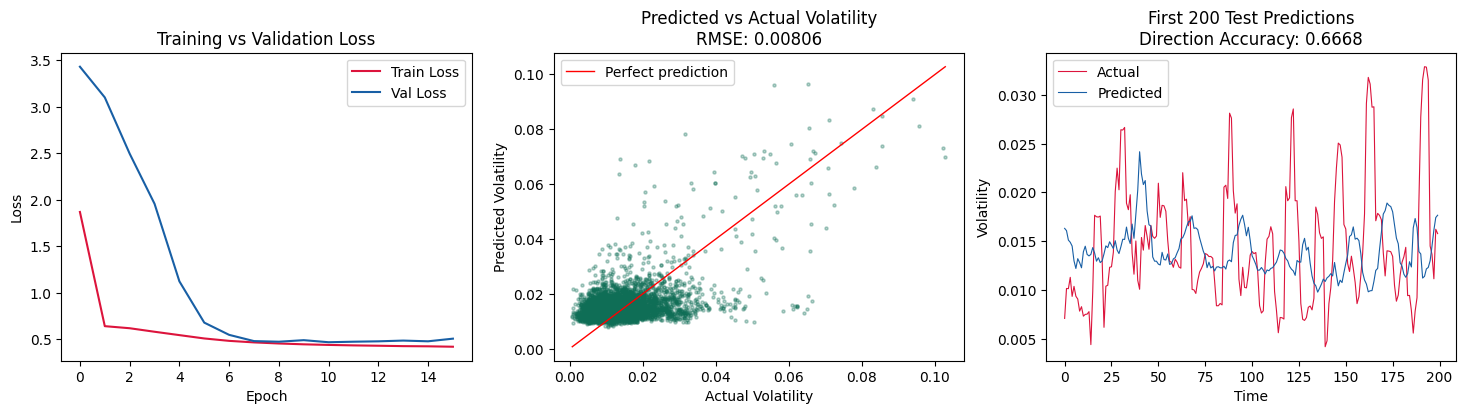

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

#graph 1:Training vs Validation Loss
axes[0].plot(train_losses, label="Train Loss", color="crimson")
axes[0].plot(val_losses, label="Val Loss",   color="#185FA5")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

#graph 2:Predicted vs Actual Volatility
axes[1].scatter(all_reg_actual, all_reg_preds, alpha=0.3, s=5, color="#0F6E56")
axes[1].plot([min(all_reg_actual), max(all_reg_actual)],
             [min(all_reg_actual), max(all_reg_actual)],
             color="red", linewidth=1, label="Perfect prediction")
axes[1].set_title(f"Predicted vs Actual Volatility\nRMSE: {rmse:.5f}")
axes[1].set_xlabel("Actual Volatility")
axes[1].set_ylabel("Predicted Volatility")
axes[1].legend()

#graph 3: First 200 predictions vs actual
axes[2].plot(all_reg_actual[:200], label="Actual",    color="crimson",  linewidth=0.8)
axes[2].plot(all_reg_preds[:200], label="Predicted", color="#185FA5", linewidth=0.8)
axes[2].set_title(f"First 200 Test Predictions\nDirection Accuracy: {accuracy:.4f}")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Volatility")
axes[2].legend()

plt.show()


In [ ]:
torch.save(model.state_dict(), "data/lstm_volatility_model.pth")
print("\nModel saved to data/lstm_volatility_model.pth")


Model saved to data/lstm_volatility_model.pth
